# Week 4: Linear Regression in Practice

This notebook develops a sequence of regression models using the **Auto MPG dataset**. The goal is to show how linear regression can be extended from one predictor to multiple predictors, and then to nonlinear relationships represented through polynomial features.

We will conduct three experiments:

1. **Simple linear regression:** Predict fuel economy (`mpg`) using vehicle `weight`. We first calculate the regression line directly from the Pearson correlation coefficient, then evaluate the fitted model using MAE, RMSE, and $R^2$.

2. **Multiple linear regression:** Use all suitable predictors in the dataset. Missing numerical values are imputed, and the categorical feature `origin` is one-hot encoded before fitting the model.

3. **Polynomial regression with model selection:** Investigate whether nonlinear relationships can further improve performance by adding polynomial terms for `weight`, `horsepower`, and `displacement`. We compare polynomial degrees 1 through 5 using an 80/10/10 training, validation, and test split. The training set is used to fit each candidate model, the validation set is used to select the polynomial degree, and the selected model is then refitted on the complete development set.

All three models use the same development and test observations, allowing their generalization performance to be compared consistently. For polynomial regression, the test set is not used until after the polynomial degree has been selected using the validation set.

The first two experiments demonstrate how performance changes as additional predictors are included. The third introduces the complete training/validation/test workflow, including hyperparameter selection, refitting on the development set, and final evaluation on unseen data.

Finally, Experiment 3 introduces the foundational concept of a **pipeline**, which combines preprocessing and modeling into a single workflow. The pipeline ensures that each transformation is learned from the appropriate training data and then applied consistently to the validation and test sets.

In [1]:
# ------------------------------------------------------------
# Imports
# ------------------------------------------------------------

# Core libraries
import numpy as np
import pandas as pd

# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import FuncFormatter

# Machine learning
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import (
    OneHotEncoder,
    PolynomialFeatures,
    StandardScaler
)

#### Load the Auto MPG Dataset from Seaborn

In [2]:
# ------------------------------------------------------------
# Load the Auto MPG dataset
# ------------------------------------------------------------

mpg_data = sns.load_dataset("mpg")

display(mpg_data.head())

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,name
0,18.0,8,307.0,130.0,3504,12.0,70,usa,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693,11.5,70,usa,buick skylark 320
2,18.0,8,318.0,150.0,3436,11.0,70,usa,plymouth satellite
3,16.0,8,304.0,150.0,3433,12.0,70,usa,amc rebel sst
4,17.0,8,302.0,140.0,3449,10.5,70,usa,ford torino


In [3]:
mpg_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           398 non-null    float64
 1   cylinders     398 non-null    int64  
 2   displacement  398 non-null    float64
 3   horsepower    392 non-null    float64
 4   weight        398 non-null    int64  
 5   acceleration  398 non-null    float64
 6   model_year    398 non-null    int64  
 7   origin        398 non-null    object 
 8   name          398 non-null    object 
dtypes: float64(4), int64(3), object(2)
memory usage: 28.1+ KB


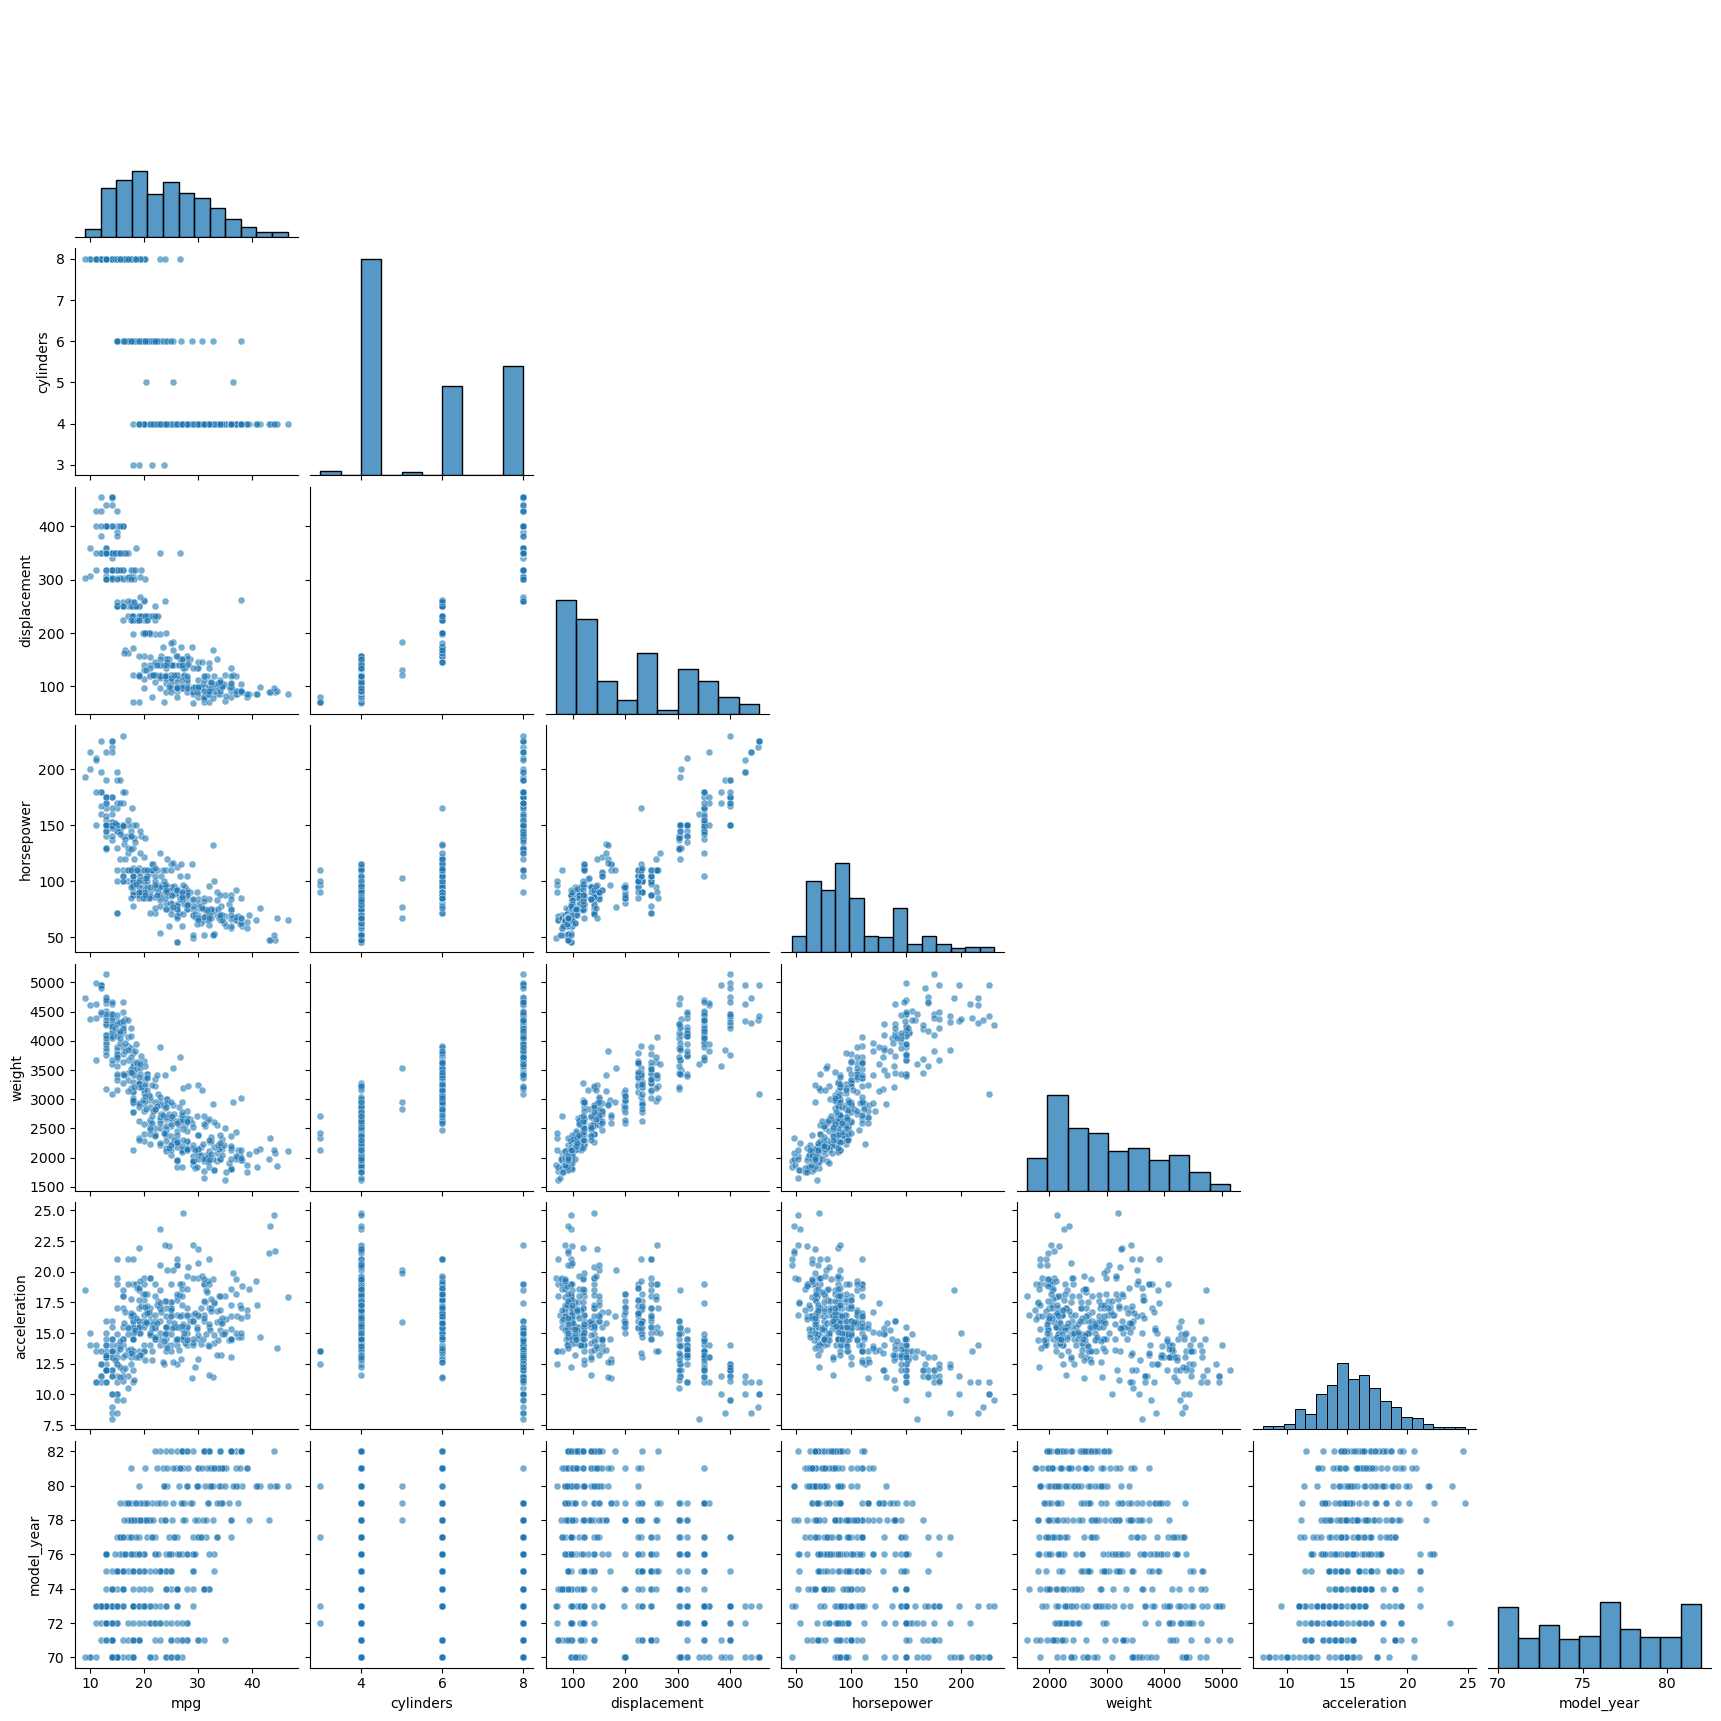

In [4]:
numeric_data = mpg_data.select_dtypes(include="number")

sns.pairplot(
    numeric_data,
    diag_kind="hist",
    corner=True,
    plot_kws={
        "alpha": 0.6,
        "s": 25
    }
)

plt.show()

### Perform the training/validation/test split

Before fitting any models, we divide the data into three separate sets:

- the **training set**, used to fit candidate models;
- the **validation set**, used to compare candidate models and select the polynomial degree;
- the **test set**, used to evaluate models on observations that were not used for fitting or model selection.

We also retain the **development set**, which combines the training and validation observations. After selecting the final model, we will refit it on the complete development set before evaluating it on the untouched test set.

Using the same split for all three regression approaches ensures that their final test results can be compared fairly.

In [5]:
# ------------------------------------------------------------
# Separate the Predictors and Target
# ------------------------------------------------------------

X_all = mpg_data.drop(
    columns=["mpg", "name"]
)

y_all = mpg_data["mpg"]


# ------------------------------------------------------------
# Create Training, Validation, and Test Sets
# ------------------------------------------------------------

# First reserve 10% of the observations for final testing
X_development, X_test, y_development, y_test = train_test_split(
    X_all,
    y_all,
    test_size=0.10,
    random_state=42
)

# Reserve 1/9 of the development set for validation:
# (1/9) × 90% = 10% of the complete dataset
X_train, X_validation, y_train, y_validation = train_test_split(
    X_development,
    y_development,
    test_size=1 / 9,
    random_state=42
)


# ------------------------------------------------------------
# Report the Split Sizes
# ------------------------------------------------------------

print(f"Training set:    {X_train.shape} {y_train.shape}")
print(f"Validation set:  {X_validation.shape}  {y_validation.shape}")
print(f"Development set: {X_development.shape} {y_development.shape}")
print(f"Test set:        {X_test.shape}  {y_test.shape}")

Training set:    (318, 7) (318,)
Validation set:  (40, 7)  (40,)
Development set: (358, 7) (358,)
Test set:        (40, 7)  (40,)


### 3.1: Simple Linear Regression Using Correlation

Our first examples will involve 1 feature and 1 target, so that we can easily view the data points as a 2D plot; this
case also illustrates the close connection between correlation and the slope of the regression line. 

Specifically, we calculate the Pearson correlation coefficient $r$, then use the formulas

$$
\beta_1 = r\frac{\sigma_y}{\sigma_x}
$$

and

$$
\beta_0 = \bar{y} - \beta_1\bar{x}
$$

to determine the slope ($\beta_1$) and intercept ($\beta_0$) of the regression line. We then use this model to predict fuel economy (MPG), visualize the fitted line, and evaluate its performance using MAE, RMSE, and $R^2$.

#### Isolate just one feature and the target

In [6]:
# ------------------------------------------------------------
# Select the Predictor for Simple Linear Regression
# ------------------------------------------------------------

X_simple_development = X_development[["weight"]]
X_simple_test = X_test[["weight"]]


print(f"Development set: {X_simple_development.shape} {y_development.shape}")
print(f"Test set:        {X_simple_test.shape}  {y_test.shape}")

Development set: (358, 1) (358,)
Test set:        (40, 1)  (40,)


Simple Linear Regression Using Correlation
------------------------------------------
Pearson correlation: -0.8307
Mean weight:         2,961.5391 pounds
Mean MPG:            23.5567
Std weight:          836.9084 pounds
Std MPG:             7.8130

Prediction equation:
Predicted MPG = 46.5226 -0.007755 × Weight

Development-Set Performance
---------------------------
MAE:  3.2912 MPG
RMSE: 4.3440 MPG
R²:   0.6900

Test-Set Performance
--------------------
MAE:  3.3628 MPG
RMSE: 4.2463 MPG
R²:   0.7061


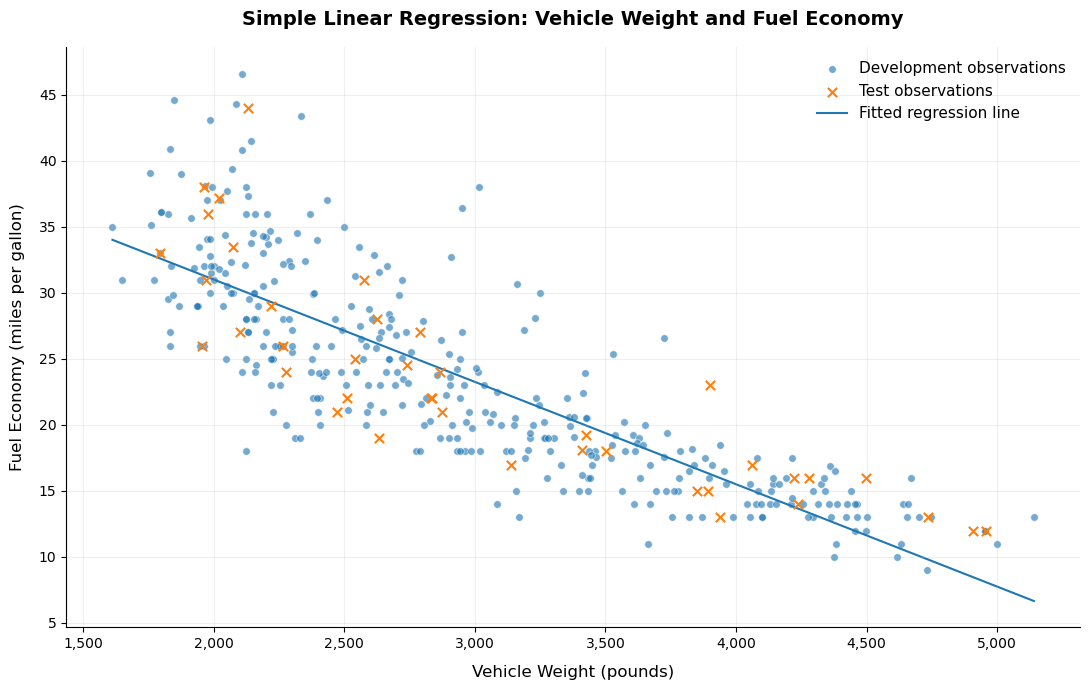

In [7]:
# ------------------------------------------------------------
# Calculate the Regression Line Using the Development Set
# ------------------------------------------------------------

# Extract vehicle weight as a one-dimensional Series
x_development = X_simple_development["weight"]

# Calculate the quantities needed for the regression formulas
# using only the development data
x_mean = x_development.mean()
y_mean = y_development.mean()

x_std = x_development.std(ddof=1)
y_std = y_development.std(ddof=1)

correlation = x_development.corr(y_development)

# Calculate the slope and intercept:
#
#     slope     = r(s_y / s_x)
#     intercept = y_mean - slope * x_mean
#
slope = correlation * (y_std / x_std)
intercept = y_mean - slope * x_mean


# ------------------------------------------------------------
# Calculate Development-Set Predictions and Metrics
# ------------------------------------------------------------

development_pred = (
    intercept
    + slope * x_development
)

development_mse = mean_squared_error(
    y_development,
    development_pred
)

development_rmse = np.sqrt(
    development_mse
)

development_mae = mean_absolute_error(
    y_development,
    development_pred
)

development_r2 = r2_score(
    y_development,
    development_pred
)


# ------------------------------------------------------------
# Calculate Test-Set Predictions and Metrics
# ------------------------------------------------------------

# Apply the completed regression equation to observations
# that were not used to estimate the slope or intercept
x_test = X_simple_test["weight"]

test_pred = (
    intercept
    + slope * x_test
)

test_mse = mean_squared_error(
    y_test,
    test_pred
)

test_rmse = np.sqrt(
    test_mse
)

test_mae = mean_absolute_error(
    y_test,
    test_pred
)

test_r2 = r2_score(
    y_test,
    test_pred
)


# ------------------------------------------------------------
# Report the Fitted Model
# ------------------------------------------------------------

print("Simple Linear Regression Using Correlation")
print("------------------------------------------")

print(f"Pearson correlation: {correlation:.4f}")
print(f"Mean weight:         {x_mean:,.4f} pounds")
print(f"Mean MPG:            {y_mean:.4f}")
print(f"Std weight:          {x_std:,.4f} pounds")
print(f"Std MPG:             {y_std:.4f}")

print(
    "\nPrediction equation:\n"
    f"Predicted MPG = {intercept:.4f} "
    f"{slope:+.6f} × Weight"
)


# ------------------------------------------------------------
# Report Development and Test Performance
# ------------------------------------------------------------

print("\nDevelopment-Set Performance")
print("---------------------------")
print(f"MAE:  {development_mae:.4f} MPG")
print(f"RMSE: {development_rmse:.4f} MPG")
print(f"R²:   {development_r2:.4f}")

print("\nTest-Set Performance")
print("--------------------")
print(f"MAE:  {test_mae:.4f} MPG")
print(f"RMSE: {test_rmse:.4f} MPG")
print(f"R²:   {test_r2:.4f}")


# ------------------------------------------------------------
# Generate a Smooth Regression Line for Plotting
# ------------------------------------------------------------

weight_line = np.linspace(
    x_development.min(),
    x_development.max(),
    300
)

mpg_line = (
    intercept
    + slope * weight_line
)


# ------------------------------------------------------------
# Create the Visualization
# ------------------------------------------------------------

fig, ax = plt.subplots(figsize=(11, 7))

# Plot the development observations used to fit the model
ax.scatter(
    x_development,
    y_development,
    s=30,
    alpha=0.62,
    edgecolor="white",
    linewidth=0.6,
    label="Development observations",
    zorder=1
)

# Plot the untouched test observations separately
ax.scatter(
    x_test,
    y_test,
    s=45,
    marker="x",
    label="Test observations",
    zorder=2
)

# Plot the fitted regression line
ax.plot(
    weight_line,
    mpg_line,
    linewidth=1.5,
    label="Fitted regression line",
    zorder=1
)


# ------------------------------------------------------------
# Labels and Formatting
# ------------------------------------------------------------

ax.set_title(
    "Simple Linear Regression: Vehicle Weight and Fuel Economy",
    fontsize=14,
    fontweight="bold",
    pad=16
)

ax.set_xlabel(
    "Vehicle Weight (pounds)",
    fontsize=12,
    labelpad=10
)

ax.set_ylabel(
    "Fuel Economy (miles per gallon)",
    fontsize=12,
    labelpad=10
)

ax.xaxis.set_major_formatter(
    FuncFormatter(
        lambda value, position: f"{value:,.0f}"
    )
)

ax.grid(alpha=0.20)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.legend(
    frameon=False,
    fontsize=11,
    loc="upper right"
)

plt.tight_layout()
plt.show()

### 3.2: Multiple Linear Regression 

We now extend the model from one predictor to all suitable predictors in the dataset.

The model will be fitted using the development data. Missing numerical values will be imputed, and the categorical feature `origin` will be one-hot encoded before fitting the regression model.

#### Preprocess the features and fit the model

We will first perform data preparation as a sequence of separate **transformations**.

Each scikit-learn transformer follows the same two-step process:

1. **Fit:** learn any information needed from the data, such as feature medians or category levels.
2. **Transform:** use that information to produce the processed features.

For now, we will apply each transformer explicitly so that we can see every step. In the next section, we will combine these steps into a **pipeline** to facilitate data preparation and model selection.

In [8]:
# ------------------------------------------------------------
# Identify Numerical and Categorical Features
# ------------------------------------------------------------

# Separate predictors according to their stored data types
numerical_features = (
    X_development
    .select_dtypes(include="number")
    .columns
    .tolist()
)

categorical_features = (
    X_development
    .select_dtypes(exclude="number")
    .columns
    .tolist()
)


# ------------------------------------------------------------
# Transform the Numerical Features
# ------------------------------------------------------------

# Learn feature medians from the development set and use them
# to replace missing values
numerical_imputer = SimpleImputer(
    strategy="median"
)

X_development_numerical = numerical_imputer.fit_transform(
    X_development[numerical_features]
)


# ------------------------------------------------------------
# Impute the Categorical Features
# ------------------------------------------------------------

# Learn the most frequent category from the development set
# and use it to replace missing values
categorical_imputer = SimpleImputer(
    strategy="most_frequent"
)

X_development_categorical_imputed = (
    categorical_imputer.fit_transform(
        X_development[categorical_features]
    )
)


# ------------------------------------------------------------
# Encode the Categorical Features
# ------------------------------------------------------------

encoder = OneHotEncoder(
    handle_unknown="ignore",
    sparse_output=False
)

X_development_categorical = encoder.fit_transform(
    X_development_categorical_imputed
)


# ------------------------------------------------------------
# Combine the Processed Features
# ------------------------------------------------------------

X_development_processed = np.hstack([
    X_development_numerical,
    X_development_categorical
])


# ------------------------------------------------------------
# Create and Fit the Model
# ------------------------------------------------------------

# Preprocessing and model fitting use only the development set.
# The untouched test set will be transformed and evaluated later.
linear_model = LinearRegression()

linear_model.fit(
    X_development_processed,
    y_development
);

Multiple Linear Regression
--------------------------

Development-Set Performance
---------------------------
MAE : 2.5155 MPG
RMSE: 3.2738 MPG
R²  : 0.8239

Test-Set Performance
--------------------
MAE : 2.6030 MPG
RMSE: 3.2631 MPG
R²  : 0.8264


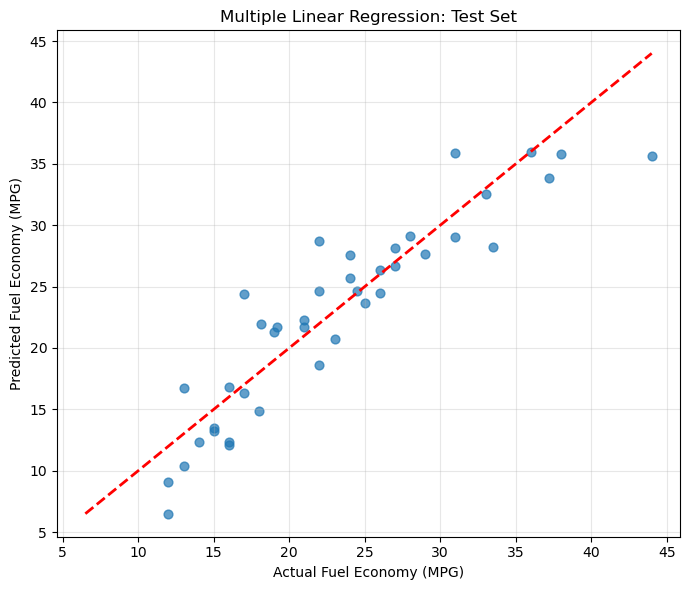

In [9]:
# ------------------------------------------------------------
# Transform the Test Set
# ------------------------------------------------------------

# Use the preprocessing objects already fitted on the
# development set. Do not fit them again on the test set.
X_test_numerical = numerical_imputer.transform(
    X_test[numerical_features]
)

X_test_categorical_imputed = categorical_imputer.transform(
    X_test[categorical_features]
)

X_test_categorical = encoder.transform(
    X_test_categorical_imputed
)

X_test_processed = np.hstack([
    X_test_numerical,
    X_test_categorical
])


# ------------------------------------------------------------
# Generate Predictions
# ------------------------------------------------------------

y_development_pred = linear_model.predict(
    X_development_processed
)

y_test_pred = linear_model.predict(
    X_test_processed
)


# ------------------------------------------------------------
# Calculate Development-Set Metrics
# ------------------------------------------------------------

development_mae = mean_absolute_error(
    y_development,
    y_development_pred
)

development_rmse = np.sqrt(
    mean_squared_error(
        y_development,
        y_development_pred
    )
)

development_r2 = r2_score(
    y_development,
    y_development_pred
)


# ------------------------------------------------------------
# Calculate Test-Set Metrics
# ------------------------------------------------------------

test_mae = mean_absolute_error(
    y_test,
    y_test_pred
)

test_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        y_test_pred
    )
)

test_r2 = r2_score(
    y_test,
    y_test_pred
)


# ------------------------------------------------------------
# Report Results
# ------------------------------------------------------------

print("Multiple Linear Regression")
print("--------------------------")

print("\nDevelopment-Set Performance")
print("---------------------------")
print(f"MAE : {development_mae:.4f} MPG")
print(f"RMSE: {development_rmse:.4f} MPG")
print(f"R²  : {development_r2:.4f}")

print("\nTest-Set Performance")
print("--------------------")
print(f"MAE : {test_mae:.4f} MPG")
print(f"RMSE: {test_rmse:.4f} MPG")
print(f"R²  : {test_r2:.4f}")


# ------------------------------------------------------------
# Actual Versus Predicted Test Values
# ------------------------------------------------------------

plt.figure(figsize=(7, 6))

plt.scatter(
    y_test,
    y_test_pred,
    alpha=0.7,
    s=40
)

minimum = min(
    y_test.min(),
    y_test_pred.min()
)

maximum = max(
    y_test.max(),
    y_test_pred.max()
)

# Perfect-prediction reference line
plt.plot(
    [minimum, maximum],
    [minimum, maximum],
    "r--",
    linewidth=2
)

plt.xlabel("Actual Fuel Economy (MPG)")
plt.ylabel("Predicted Fuel Economy (MPG)")
plt.title("Multiple Linear Regression: Test Set")
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

### 3.3: Polynomial Regression with Model Selection and a Pipeline

In the pair plot generated during EDA, we observed that three features—`horsepower`, `displacement`, and `weight`—have nonlinear relationships with the target, possibly including quadratic curvature. It is therefore worth investigating whether adding polynomial terms for these features produces a better model.

We will compare polynomial regression models with degrees $1,\ldots,5$.

The training, validation, and test sets have already been created:

- the **training set** will be used to fit each candidate polynomial model;
- the **validation set** will be used to select the polynomial degree;
- the **test set** will remain untouched until the final model has been selected.

After choosing the degree with the lowest validation MAE, we will refit that model on the complete development set and evaluate it once on the test set.

This section also introduces a **pipeline**, which combines preprocessing and model fitting into a single workflow.

In [10]:
# ------------------------------------------------------------
# Prepare the Polynomial Regression Predictors
# ------------------------------------------------------------

# These predictors will receive polynomial terms
polynomial_features = [
    "horsepower",
    "displacement",
    "weight"
]

# Identify numerical and categorical predictors
numerical_features = (
    X_development
    .select_dtypes(include="number")
    .columns
    .tolist()
)

categorical_features = (
    X_development
    .select_dtypes(exclude="number")
    .columns
    .tolist()
)

# Numerical predictors that will remain unchanged
remaining_numerical_features = [
    feature
    for feature in numerical_features
    if feature not in polynomial_features
]


# ------------------------------------------------------------
# Confirm the Existing Data Splits
# ------------------------------------------------------------

print(f"Training set:    {X_train.shape} {y_train.shape}")
print(f"Validation set:  {X_validation.shape} {y_validation.shape}")
print(f"Development set: {X_development.shape} {y_development.shape}")
print(f"Test set:        {X_test.shape} {y_test.shape}")

Training set:    (318, 7) (318,)
Validation set:  (40, 7) (40,)
Development set: (358, 7) (358,)
Test set:        (40, 7) (40,)


We will now write a function that creates a pipeline for each polynomial degree we want to evaluate.

We will use `make_pipeline`, which links data preprocessing steps together sequentially, passing the output of one stage to the next.

    Pipeline
    ========

    A → B → C → D

(Another option is `Pipeline`, which names each step, to allow more granular control and inspection.)

We also need a `ColumnTransformer`, which applies different transformations to different groups of columns and then combines the resulting features.

    ColumnTransformer
    =================

            ┌─► A ──┐
    Columns ├─► B ──┼──► combine
            └─► C ──┘

For this experiment, `create_polynomial_model(degree)` will return a pipeline that performs the preprocessing and modeling steps shown here:

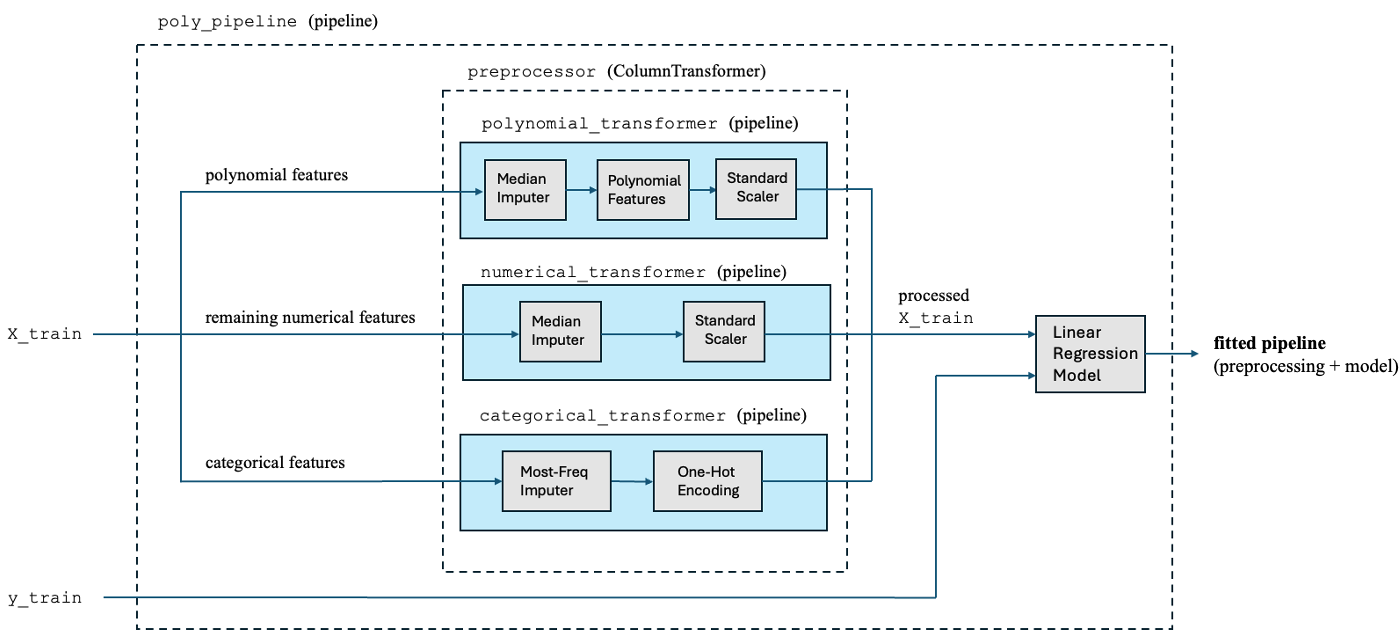

In [17]:
# ------------------------------------------------------------
# Function to Construct a Pipeline for a Specified Degree
# ------------------------------------------------------------

def create_polynomial_model(degree):
    """Create the preprocessing and regression pipeline."""

    # Impute selected numerical predictors, create polynomial
    # terms, and scale them to improve numerical conditioning
    polynomial_transformer = make_pipeline(
        SimpleImputer(strategy="median"),

        PolynomialFeatures(
            degree=degree,
            include_bias=False
        ),

        StandardScaler()
    )

    # Impute and scale numerical predictors that are not expanded
    numerical_transformer = make_pipeline(
        SimpleImputer(strategy="median"),
    
        StandardScaler()
    )

    # Impute and one-hot encode categorical predictors
    categorical_transformer = make_pipeline(
        SimpleImputer(strategy="most_frequent"),

        OneHotEncoder(
            handle_unknown="ignore",
            sparse_output=False
        )
    )

    # Apply the appropriate transformations to each
    # group of predictors
    preprocessor = ColumnTransformer(
        [
            (
                "polynomial",
                polynomial_transformer,
                polynomial_features
            ),
            (
                "numerical",
                numerical_transformer,
                remaining_numerical_features
            ),
            (
                "categorical",
                categorical_transformer,
                categorical_features
            )
        ]
    )

    # Combine preprocessing and regression
    # into one pipeline
    polynomial_pipeline = make_pipeline(
        preprocessor,
        LinearRegression()
    )

    return polynomial_pipeline

# Display the pipeline structure for a quadratic model
display(
    create_polynomial_model(degree=2)
)

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(transformers=[('polynomial',
                                                  Pipeline(steps=[('simpleimputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('polynomialfeatures',
                                                                   PolynomialFeatures(include_bias=False)),
                                                                  ('standardscaler',
                                                                   StandardScaler())]),
                                                  ['horsepower', 'displacement',
                                                   'weight']),
                                                 ('numerical',
                                                  Pipeline(steps=[('simpleimputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('standardscaler',
                                                                   StandardScaler())]),
                                                  ['cylinders', 'acceleration',
                                                   'model_year']),
                                                 ('categorical',
                                                  Pipeline(steps=[('simpleimputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehotencoder',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  ['origin'])])),
                ('linearregression', LinearRegression())])

Degree,Training MAE,Validation MAE
1,2.5715,2.0948
2,2.1714,1.8218
3,1.9993,1.9146
4,1.9186,2.0930
5,1.7549,2.2098


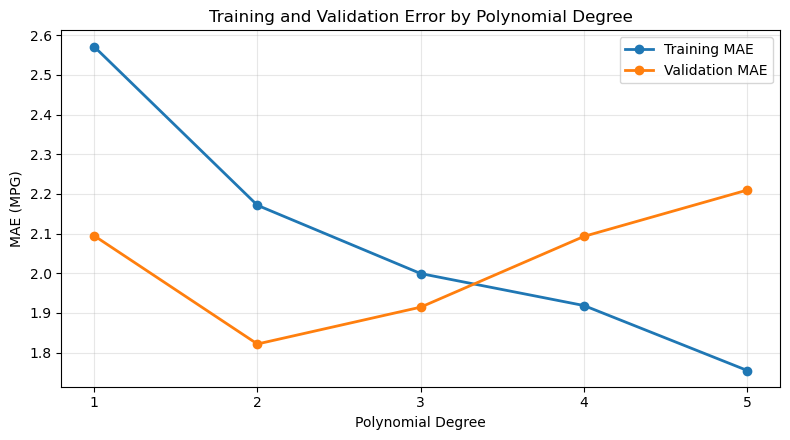

Selected degree: 2
Validation MAE: 1.8218 MPG


In [18]:
# ------------------------------------------------------------
# Fit Polynomial Models of Degrees 1 Through 5
# ------------------------------------------------------------

degrees = range(1, 6)

results = []

for degree in degrees:

    poly_model = create_polynomial_model(degree)

    # Learn all preprocessing and model parameters
    # using only the training set
    poly_model.fit(
        X_train,
        y_train
    )

    y_train_pred = poly_model.predict(
        X_train
    )

    y_validation_pred = poly_model.predict(
        X_validation
    )

    training_mae = mean_absolute_error(
        y_train,
        y_train_pred
    )

    validation_mae = mean_absolute_error(
        y_validation,
        y_validation_pred
    )

    results.append({
        "Degree": degree,
        "Training MAE": training_mae,
        "Validation MAE": validation_mae
    })


# ------------------------------------------------------------
# Display the Results
# ------------------------------------------------------------

results_df = pd.DataFrame(results)

display(
    results_df.style
    .hide(axis="index")
    .format({
        "Training MAE": "{:.4f}",
        "Validation MAE": "{:.4f}"
    })
)


# ------------------------------------------------------------
# Plot Training and Validation MAE
# ------------------------------------------------------------

plt.figure(figsize=(8, 4.5))

plt.plot(
    results_df["Degree"],
    results_df["Training MAE"],
    marker="o",
    linewidth=2,
    label="Training MAE"
)

plt.plot(
    results_df["Degree"],
    results_df["Validation MAE"],
    marker="o",
    linewidth=2,
    label="Validation MAE"
)

plt.xlabel("Polynomial Degree")
plt.ylabel("MAE (MPG)")
plt.title(
    "Training and Validation Error by Polynomial Degree"
)
plt.xticks(list(degrees))
plt.grid(alpha=0.3)
# plt.ylim(0, 3.5)
plt.legend()
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# Select the Degree with the Lowest Validation MAE
# ------------------------------------------------------------

best_row = results_df.loc[
    results_df["Validation MAE"].idxmin()
]

best_degree = int(
    best_row["Degree"]
)

best_validation_mae = (
    best_row["Validation MAE"]
)

print(f"Selected degree: {best_degree}")
print(
    f"Validation MAE: "
    f"{best_validation_mae:.4f} MPG"
)


# ------------------------------------------------------------
# Refit the Selected Model on the Development Set
# ------------------------------------------------------------

# After model selection, refit the selected pipeline using
# all training and validation observations
final_poly_model = create_polynomial_model(
    best_degree
)

final_poly_model.fit(                       
    X_development,
    y_development
);

### Final Evaluation on the Test Set

After selecting degree 2 using the validation set, we refitted the polynomial regression pipeline on the complete development set. We now evaluate this final model on the untouched test set to estimate how well it generalizes to new data.

The test set was not used to fit the model or select the polynomial degree.

In [13]:
# ------------------------------------------------------------
# Evaluate the Selected Polynomial Model
# ------------------------------------------------------------

# The selected degree-2 model has already been refitted
# on the complete development set
y_development_pred = final_poly_model.predict(
    X_development
)

y_test_pred = final_poly_model.predict(
    X_test
)


# ------------------------------------------------------------
# Calculate Development-Set Metrics
# ------------------------------------------------------------

development_mae = mean_absolute_error(
    y_development,
    y_development_pred
)

development_rmse = np.sqrt(
    mean_squared_error(
        y_development,
        y_development_pred
    )
)

development_r2 = r2_score(
    y_development,
    y_development_pred
)


# ------------------------------------------------------------
# Calculate Test-Set Metrics
# ------------------------------------------------------------

test_mae = mean_absolute_error(
    y_test,
    y_test_pred
)

test_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        y_test_pred
    )
)

test_r2 = r2_score(
    y_test,
    y_test_pred
)


# ------------------------------------------------------------
# Report Results
# ------------------------------------------------------------

print("Polynomial Regression")
print("---------------------")

print("\nDevelopment-Set Performance")
print("---------------------------")
print(f"MAE : {development_mae:.4f} MPG")
print(f"RMSE: {development_rmse:.4f} MPG")
print(f"R²  : {development_r2:.4f}")

print("\nTest-Set Performance")
print("--------------------")
print(f"MAE : {test_mae:.4f} MPG")
print(f"RMSE: {test_rmse:.4f} MPG")
print(f"R²  : {test_r2:.4f}")

Polynomial Regression
---------------------

Development-Set Performance
---------------------------
MAE : 2.1188 MPG
RMSE: 2.8748 MPG
R²  : 0.8642

Test-Set Performance
--------------------
MAE : 1.9719 MPG
RMSE: 2.6494 MPG
R²  : 0.8856


### Conclusion

| Model                           | Development MAE | Development RMSE | Development $R^2$ |   Test MAE |  Test RMSE | Test $R^2$ |
| ------------------------------- | --------------: | ---------------: | ----------------: | ---------: | ---------: | ---------: |
| Simple Linear Regression        |      3.2912 MPG |       4.3440 MPG |            0.6900 | 3.3628 MPG | 4.2463 MPG |     0.7061 |
| Multiple Linear Regression      |      2.5155 MPG |       3.2738 MPG |            0.8239 | 2.6030 MPG | 3.2631 MPG |     0.8264 |
| Polynomial Regression, Degree 2 |      2.1188 MPG |       2.8748 MPG |            0.8642 | 1.9719 MPG | 2.6494 MPG |     0.8856 |

These experiments illustrate two important ways to improve a regression model. 
- First, using multiple predictors substantially improves performance compared with predicting fuel economy from vehicle weight alone.
- Second, allowing selected predictors to enter the model through polynomial terms captures additional nonlinear structure and produces a further improvement.

Among polynomial degrees 1 through 5, degree 2 achieved the lowest validation MAE. Although higher-degree models continued to reduce training error, their validation error increased, indicating overfitting. We therefore selected the degree-2 model and refitted it on the complete development set.

The degree-2 polynomial model also achieved the best test-set performance, with the lowest MAE and RMSE and the highest $R^2.$ The development and test results are reasonably close for all three models, suggesting that the observed improvements generalize well to unseen data. Overall, the results show that a moderately flexible model can capture important nonlinear relationships in the Auto MPG data without the instability of a highly complex polynomial model.
